# Advanced In-Depth Exploratory Data Analysis

This notebook conducts an exhaustive EDA on `train_processed.csv`. We will explore feature distributions, bivariate relationships with the TARGET, identify patterns of variance, and detect anomalies. This gives us foundational intuition for modeling defaults.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

In [4]:
# Load Data
data_path = r'../Data/processed/train_processed.csv'
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (307511, 210)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_DPD_RATE,POS_CNT_INSTALMENT_MEAN,CC_COUNT,CC_CC_UTIL_RATE_MEAN,CC_CC_UTIL_RATE_MAX,CC_CC_DRAWING_RATE_MEAN,CC_AMT_BALANCE_MEAN,CC_DPD_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,24.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,10.107143,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,3.750000,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,12.000000,6.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,15.333333,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Missing Value and DataType Diagnostic

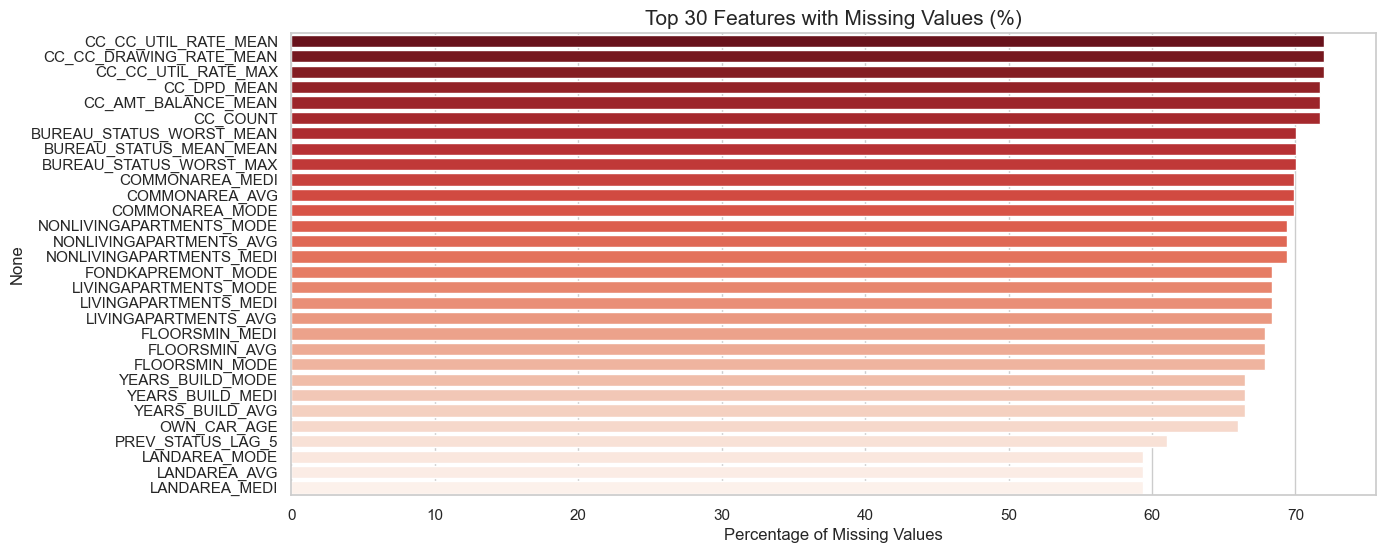

In [5]:
# Check missing value percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_vals = missing_percent[missing_percent > 0].sort_values(ascending=False)

if len(missing_vals) > 0:
    plt.figure(figsize=(14, 6))
    sns.barplot(x=missing_vals.head(30).values, y=missing_vals.head(30).index, palette='Reds_r')
    plt.title('Top 30 Features with Missing Values (%)', fontsize=15)
    plt.xlabel('Percentage of Missing Values')
    plt.show()
else:
    print("No missing values found!")

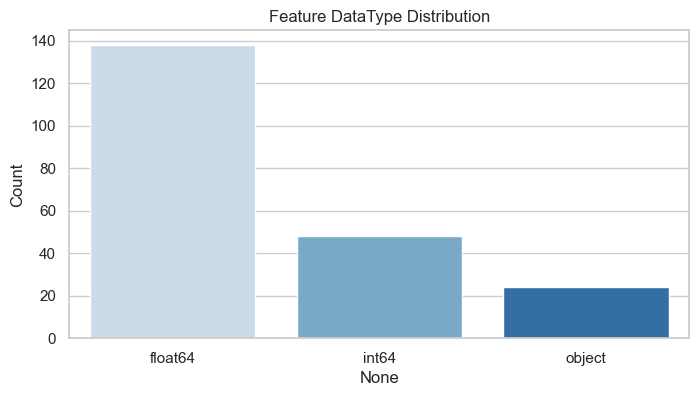

In [6]:
# Datatypes Summary
dtype_counts = df.dtypes.value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=dtype_counts.index.astype(str), y=dtype_counts.values, palette='Blues')
plt.title('Feature DataType Distribution')
plt.ylabel('Count')
plt.show()

## 2. Target Variable Analysis\nEvaluating class imbalance.

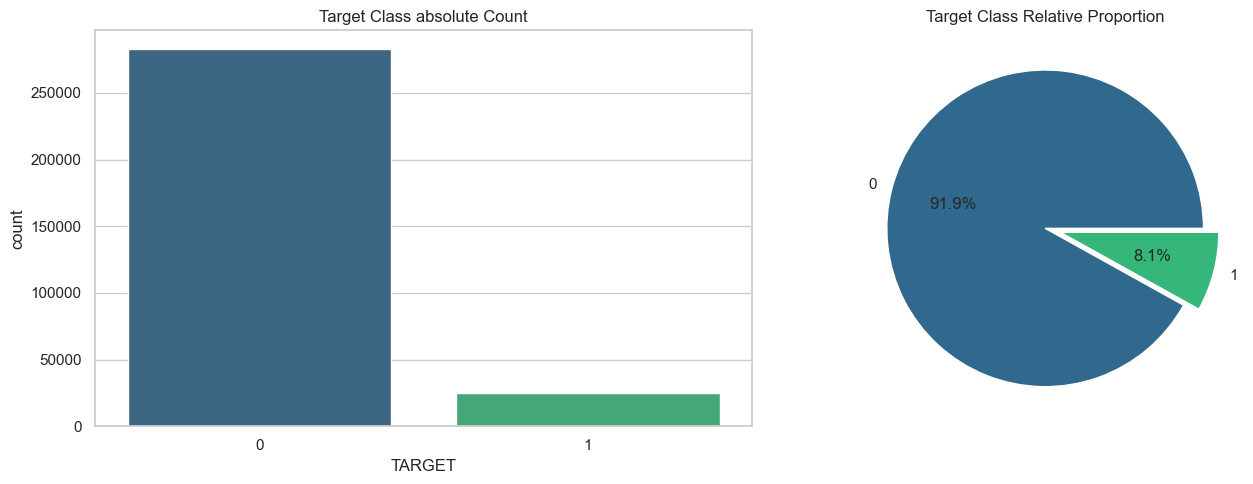

In [7]:
if 'TARGET' in df.columns:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Countplot
    sns.countplot(data=df, x='TARGET', ax=ax[0], palette='viridis')
    ax[0].set_title('Target Class absolute Count')
    
    # Pie chart
    target_counts = df['TARGET'].value_counts()
    ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', 2), explode=(0, 0.1))
    ax[1].set_title('Target Class Relative Proportion')
    
    plt.tight_layout()
    plt.show()

## 3. Top Numerical Features - KDE Distributions\nAnalyzing how numerical features separate the TARGET space.

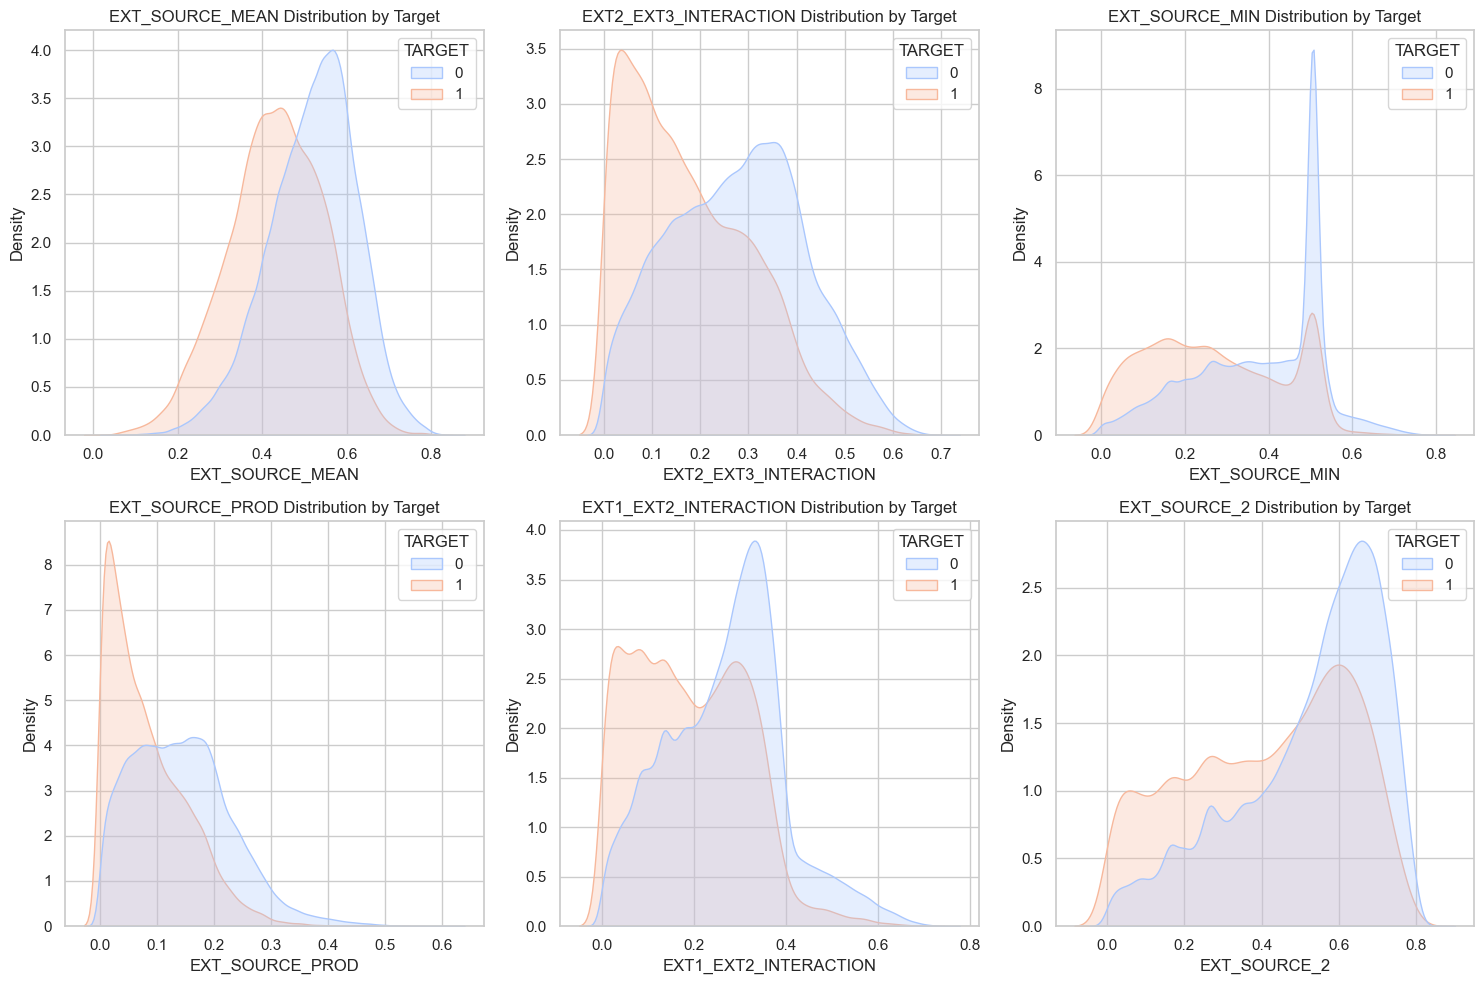

In [8]:
numeric_features = df.select_dtypes(include=[np.number]).columns.drop(['TARGET', 'SK_ID_CURR'], errors='ignore')

if 'TARGET' in df.columns:
    # Let's pick 6 top correlated features to visualize distributions safely
    corrs = df[numeric_features].corrwith(df['TARGET']).abs().sort_values(ascending=False)
    top_6_num = corrs.head(6).index
    
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(top_6_num, 1):
        plt.subplot(2, 3, i)
        sns.kdeplot(data=df, x=col, hue='TARGET', common_norm=False, fill=True, alpha=0.3, palette='coolwarm')
        plt.title(f'{col} Distribution by Target')
    plt.tight_layout()
    plt.show()

## 4. Top Categorical Features vs Target  |  Frequency of defaults across major categorical strata.

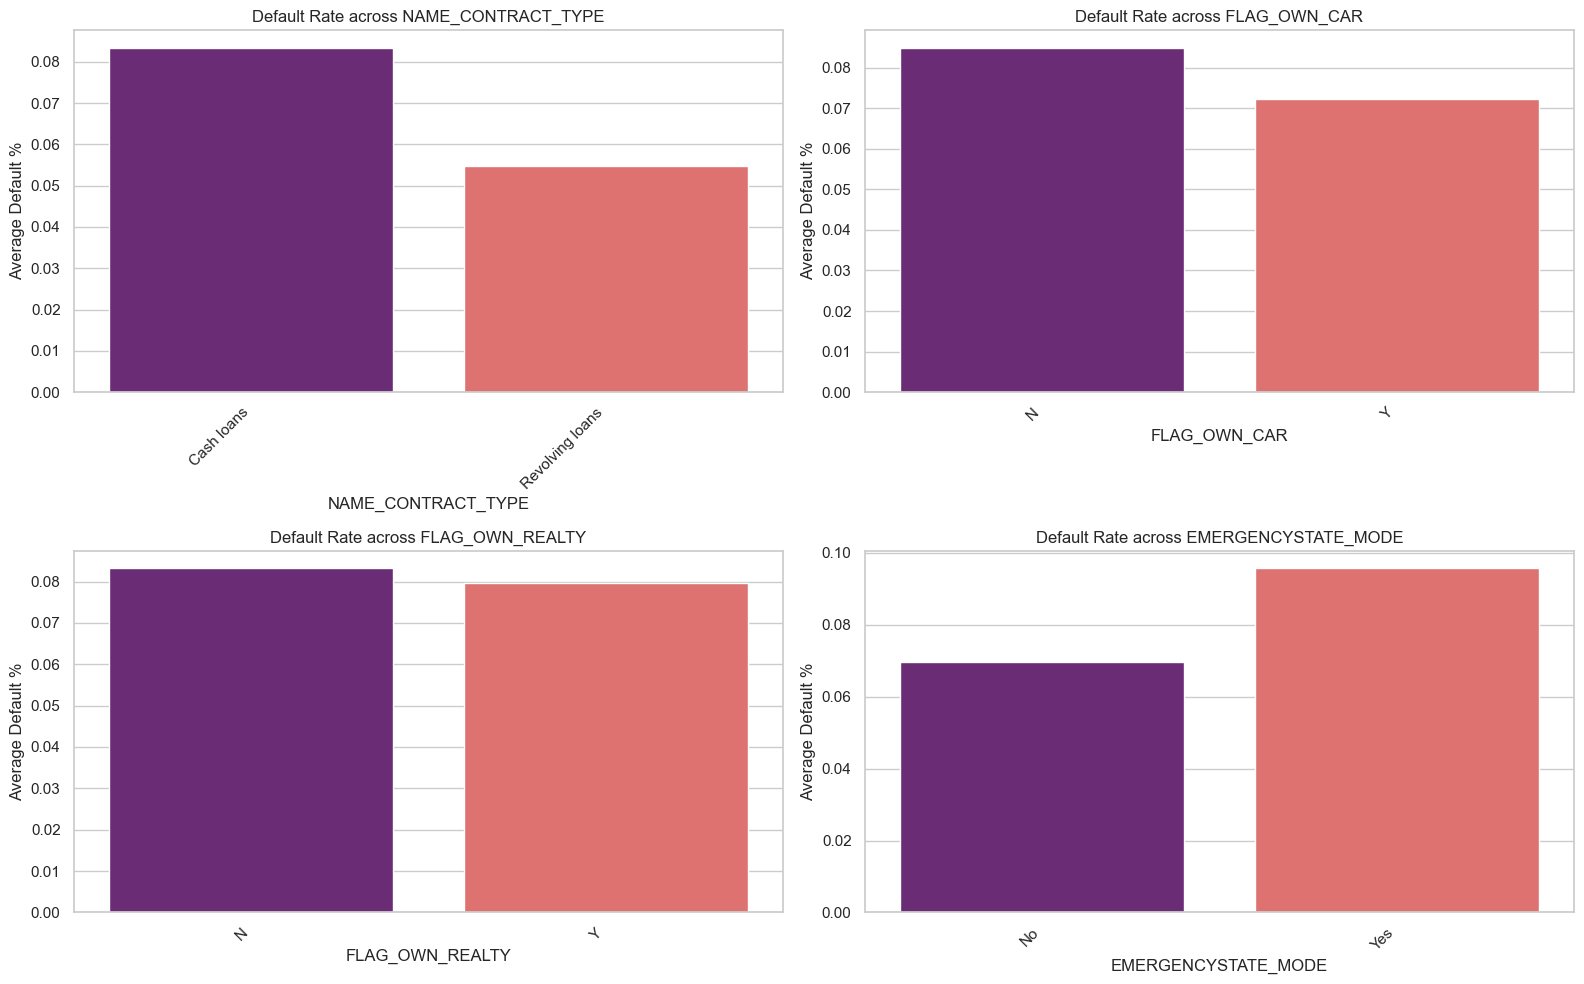

In [9]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_features) > 0 and 'TARGET' in df.columns:
    # Plot top 4 categorical features with least unique values to avoid extreme clutter
    unique_counts = df[categorical_features].nunique().sort_values()
    top_cats = unique_counts[unique_counts < 10].head(4).index
    
    plt.figure(figsize=(16, 10))
    for i, col in enumerate(top_cats, 1):
        plt.subplot(2, 2, i)
        # We calculate mean target representing the "Default Rate"
        prop_df = df.groupby(col)['TARGET'].mean().reset_index()
        sns.barplot(data=prop_df, x=col, y='TARGET', palette='magma')
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Default Rate across {col}')
        plt.ylabel('Average Default %')
    plt.tight_layout()
    plt.show()

## 5. Global Correlation Map\nMulticollinearity analysis using a cluster map logic for the highest variance continuous features.

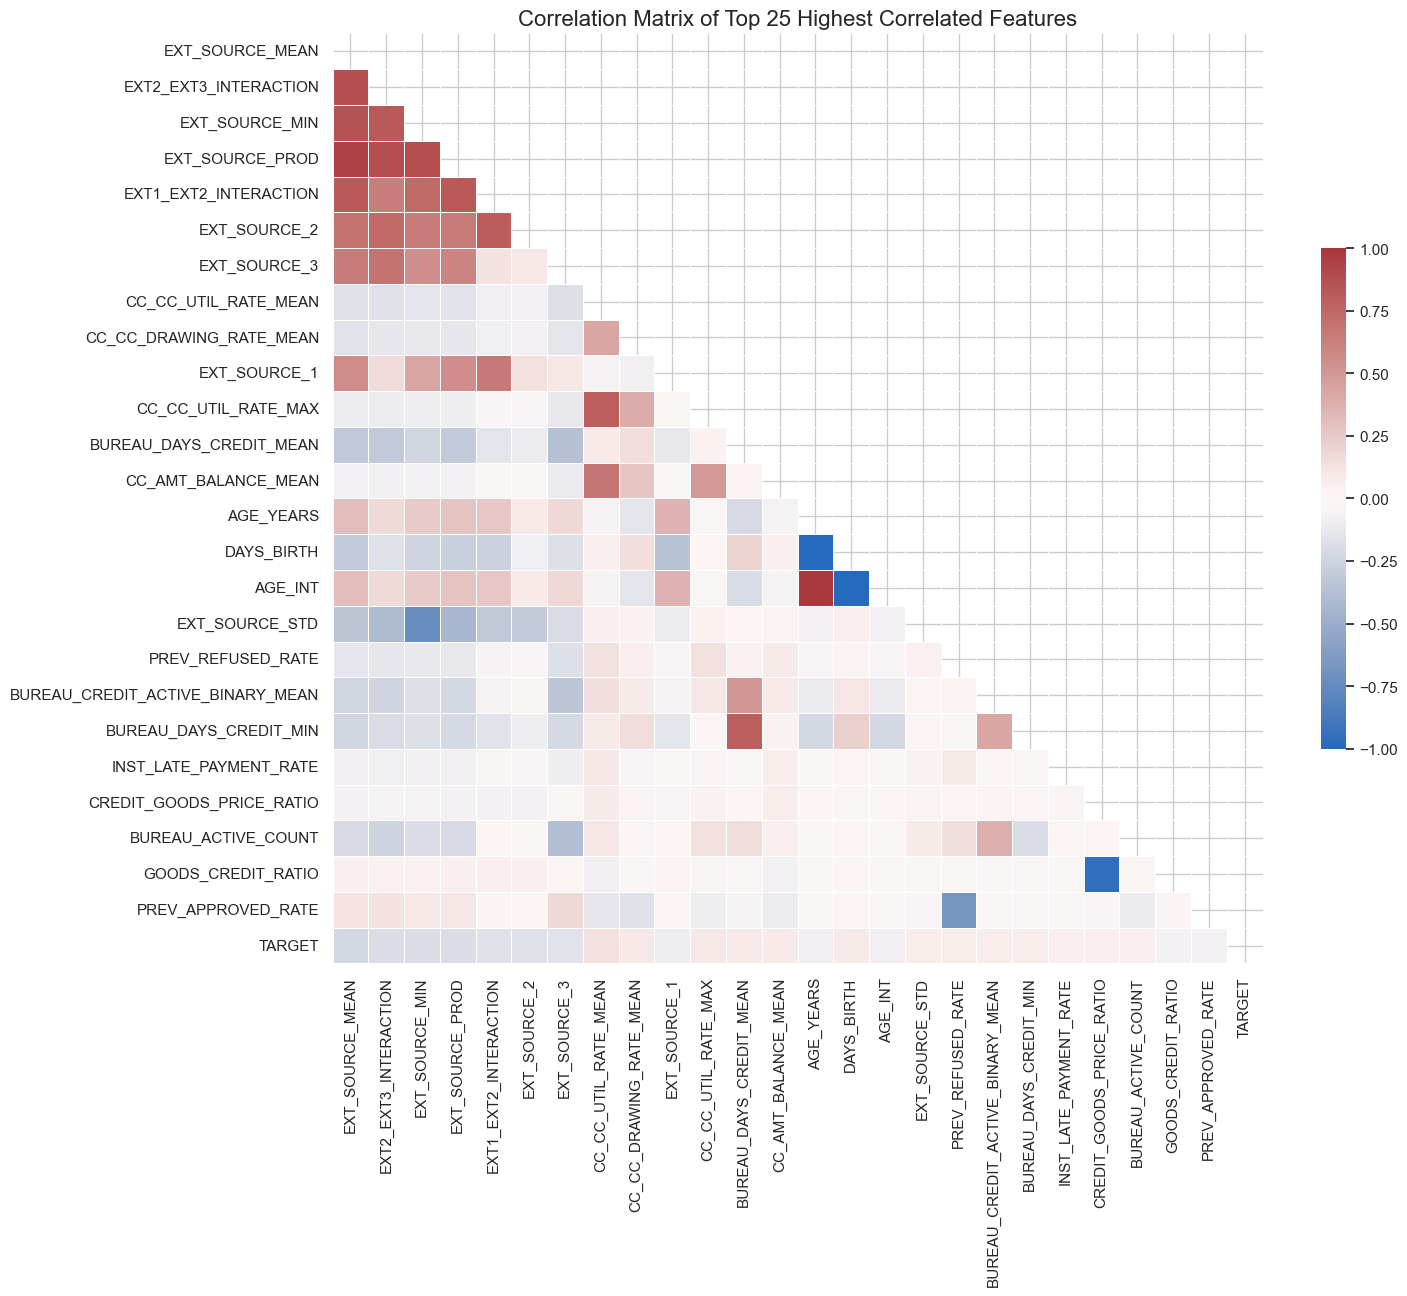

In [10]:
if 'TARGET' in df.columns:
    highly_corr = corrs.head(25).index.tolist() + ['TARGET']
    corr_matrix = df[highly_corr].corr()
    
    plt.figure(figsize=(15, 13))
    # Draw lower triangle heatmap
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='vlag', vmin=-1, vmax=1, center=0, 
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=False)
    plt.title('Correlation Matrix of Top 25 Highest Correlated Features', fontsize=16)
    plt.show()

## 6. Outlier Diagnostics Using Boxplots against the Target.

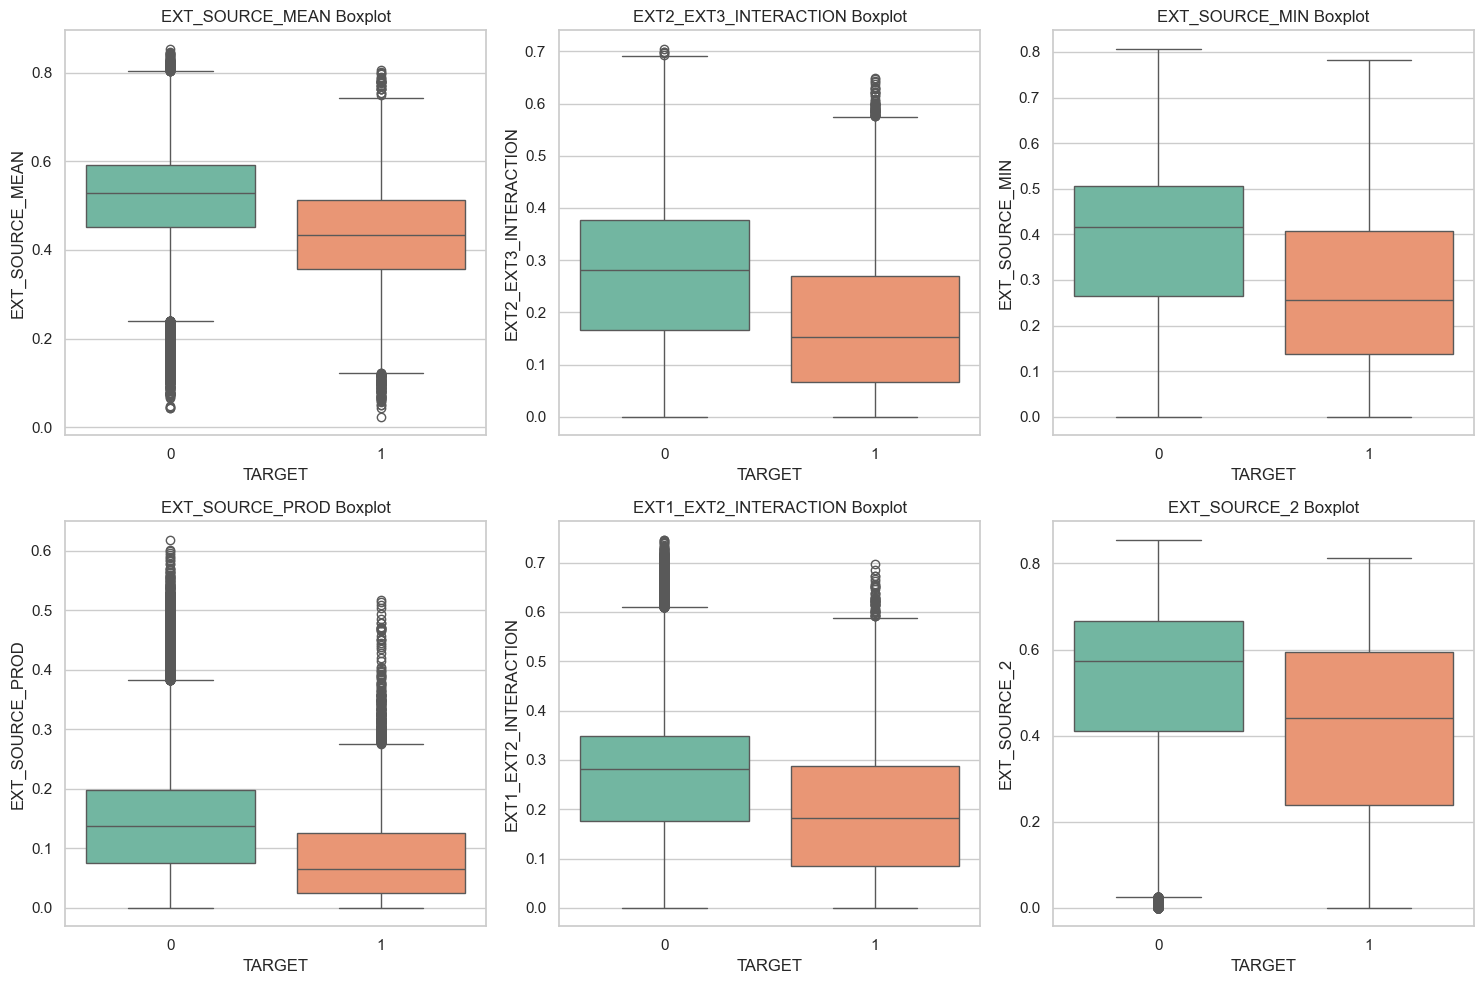

In [11]:
if len(top_6_num) > 0:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(top_6_num, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(data=df, x='TARGET', y=col, palette='Set2')
        plt.title(f'{col} Boxplot')
    plt.tight_layout()
    plt.show()